# Task 3 - Otsu's Thresholding

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

In [2]:
bgr = cv2.imread("coins.png")

if bgr is None:
    raise FileNotFoundError(
        "Place a touching-coins image as coins.png in the notebook folder."
    )

# Convert the image from BGR to RGB for displaying with Matplotlib
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# Convert the image to grayscale for image processing
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)


Otsu original threshold: 161.0
Otsu after CLAHE: 156.0


C:\Users\Hp Elitebook 840 G3\AppData\Local\Temp\ipykernel_5616\2610337220.py:42: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax[1].hist(gray.ravel(), 256, [0, 256])


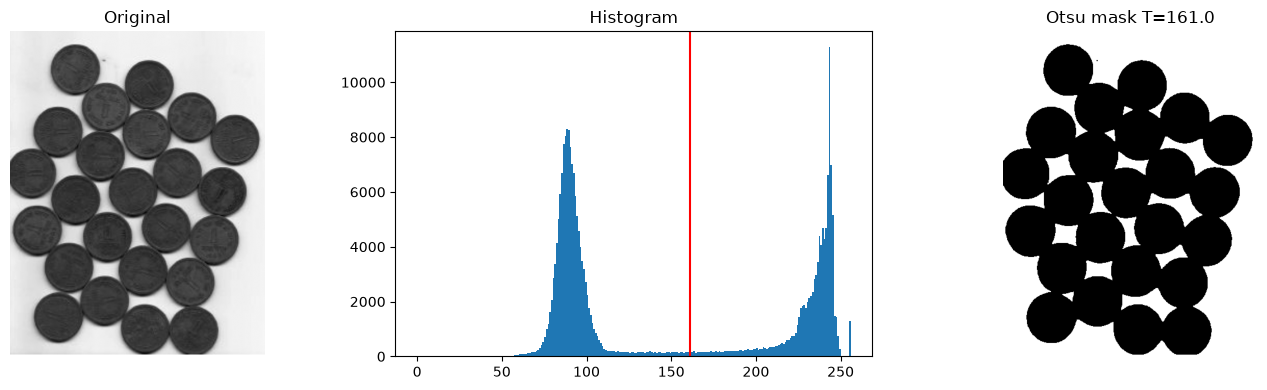

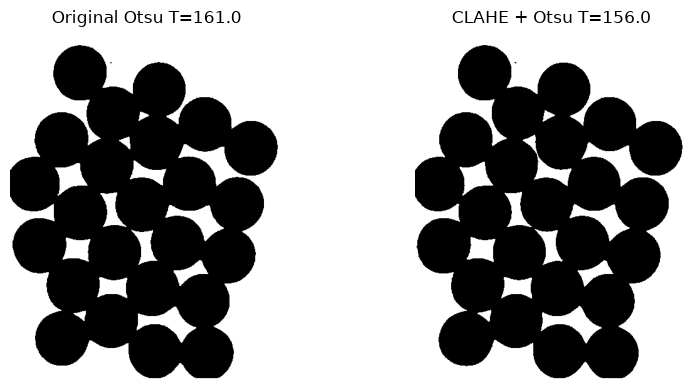

True

In [3]:
# Function to apply Otsu's automatic thresholding
def otsu(x):
    threshold, mask = cv2.threshold(
        x,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return threshold, mask


# Apply Otsu thresholding to the original grayscale image
t1, m1 = otsu(gray)

# Enhance local contrast using CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

clahe_image = clahe.apply(gray)

# Apply Otsu thresholding after CLAHE enhancement
t2, m2 = otsu(clahe_image)

# Display the calculated threshold values
print(f"Otsu original threshold: {t1:.1f}")
print(f"Otsu after CLAHE: {t2:.1f}")


# ---------------------------------------------------------
# Display original image, histogram, and Otsu threshold mask
# ---------------------------------------------------------

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Display the original grayscale image
ax[0].imshow(gray, cmap="gray")
ax[0].set_title("Original")

# Display the grayscale histogram
ax[1].hist(gray.ravel(), 256, [0, 256])
ax[1].axvline(t1, color="red")
ax[1].set_title("Histogram")

# Display the Otsu threshold mask
ax[2].imshow(m1, cmap="gray")
ax[2].set_title(f"Otsu mask T={t1:.1f}")

# Hide axes for image plots
for a in [ax[0], ax[2]]:
    a.axis("off")

# Adjust spacing and display the figure
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Compare original Otsu with CLAHE + Otsu
# ---------------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(9, 4))

# Original Otsu result
ax[0].imshow(m1, cmap="gray")
ax[0].set_title(f"Original Otsu T={t1:.1f}")

# CLAHE-enhanced Otsu result
ax[1].imshow(m2, cmap="gray")
ax[1].set_title(f"CLAHE + Otsu T={t2:.1f}")

# Hide axes
for a in ax:
    a.axis("off")

# Display the comparison
plt.tight_layout()
plt.show()


# Save the original Otsu result
cv2.imwrite(
    str(OUT / "task3_final.png"),
    m1
)


## Answer
Otsu is useful when the cutoff is unknown because it selects a threshold automatically from the image intensity distribution by maximizing separation between two classes. The contrast/preprocessing experiment demonstrates that the automatically selected value can change when the intensity distribution changes.